# HRNet Cephalometric Landmark Inference
This notebook loads your trained HRNet model, runs inference on a single Cephalometric X-ray, and visualizes the 29 predicted landmarks.

In [28]:
import os
import sys
import cv2
import numpy as np
import torch
import matplotlib.pyplot as plt

# Add current workspace to path so we can import 'lib'
sys.path.insert(0, os.path.abspath('.'))

from lib.config import config, update_config
import lib.models as models
from lib.core.evaluation import decode_preds
from lib.utils.transforms import crop_v2

### 1. Load Configurations and Model
Ensure the paths below match your actual YAML config and the best checkpoint you saved.

In [29]:
cfg_path = 'experiments/ceph/face_alignment_ceph_hrnet.yaml'
model_path = 'output/CephDataset/face_alignment_ceph_hrnet/model_best.pth'

# Mock arguments to load the yaml via your existing codebase functions
class Args:
    cfg = cfg_path
args = Args()
update_config(config, args)

# Initialize HRNet model
model = models.get_face_alignment_net(config)

# Select device once and use consistently
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Load checkpoint
loaded_obj = torch.load(model_path, weights_only=False, map_location='cpu')

# Extract a usable state_dict from different checkpoint layouts
if isinstance(loaded_obj, torch.nn.Module):
    state_dict = loaded_obj.state_dict()
elif isinstance(loaded_obj, dict) and 'state_dict' in loaded_obj:
    state_dict = loaded_obj['state_dict']
else:
    state_dict = loaded_obj

# If state_dict was saved from DataParallel, remove the "module." prefix
if isinstance(state_dict, dict):
    state_dict = {
        (k[7:] if k.startswith('module.') else k): v
        for k, v in state_dict.items()
    }

# Apply weights
model.load_state_dict(state_dict, strict=True)
model.to(device)
model.eval()

print(f"Model successfully loaded and ready for inference on {device}!")

Model successfully loaded and ready for inference on cuda!


### 2. Define Image Preprocessing
This function perfectly mimics the transformations applied during training in your `lib/datasets/ceph.py`. It centers, scales, crops, and normalizes the raw X-ray to 512x512 tensor.

In [30]:
def preprocess_image(image_path, input_size):
    img = cv2.imread(image_path)
    if img is None:
        raise ValueError(f"Could not read image at {image_path}")
        
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w, _ = img.shape
    
    # --- Match Training Logic for Center & Scale ---
    img_name = os.path.basename(image_path)
    img_dir = os.path.dirname(image_path)
    parent_dir = os.path.dirname(img_dir)
    
    # Expected annotation path based on dataset structure in training script
    anno_path = os.path.join(
        parent_dir, 'Annotations', 'Cephalometric Landmarks', 
        'Senior Orthodontists', img_name.replace('.png', '.json')
    )
    
    import json
    if os.path.exists(anno_path):
        with open(anno_path, 'r') as f:
            anno = json.load(f)
            
        pts = []
        for lm in anno['landmarks']:
            x = lm['value']['x']
            y = lm['value']['y']
            pts.append([x, y])
        pts = np.array(pts)
        
        min_x, max_x = np.min(pts[:, 0]), np.max(pts[:, 0])
        min_y, max_y = np.min(pts[:, 1]), np.max(pts[:, 1])
        
        center_x = (min_x + max_x) / 2.0
        center_y = (min_y + max_y) / 2.0
        
        if max_x - min_x < 10 or max_y - min_y < 10:
            center_x = w / 2.0
            center_y = h / 2.0
            min_x, max_x, min_y, max_y = 0, w, 0, h
            
        center = torch.Tensor([center_x, center_y])
        scale = max((max_x - min_x), (max_y - min_y)) / 200.0
        scale = scale * 1.5
    else:
        # print("⚠️ Annotation not found. Falling back to whole-image center/scale.")
        center_x = w / 2.0
        center_y = h / 2.0
        center = torch.Tensor([center_x, center_y])
        # Base scale formula: max(w, h) / standard_pixel_size * dataset_factor
        scale = max(w, h) / 200.0 * 1.5 
    
    # Crop using lib.utils.transforms.crop_v2 which matches the training behavior exactly
    center_np = center.numpy() if isinstance(center, torch.Tensor) else center
    img_cropped = crop_v2(img, center_np, scale, input_size, rot=0)
    
    # Normalize with ImageNet stats
    img_cropped = img_cropped.astype(np.float32) / 255.0
    mean = np.array([0.485, 0.456, 0.406], dtype=np.float32)
    std = np.array([0.229, 0.224, 0.225], dtype=np.float32)
    img_cropped = (img_cropped - mean) / std
    
    # Convert to PyTorch Tensor [Channels, Height, Width]
    img_tensor = torch.from_numpy(img_cropped.transpose((2, 0, 1)))
    img_tensor = img_tensor.unsqueeze(0) # Add batch dimension -> [1, C, H, W]
    
    return img_tensor, img, center, scale

### 3. Run Inference & Plot
Point `test_image_path` to an actual image file inside your dataset.

torch.Size([1, 29, 64, 64])
(29, 2)


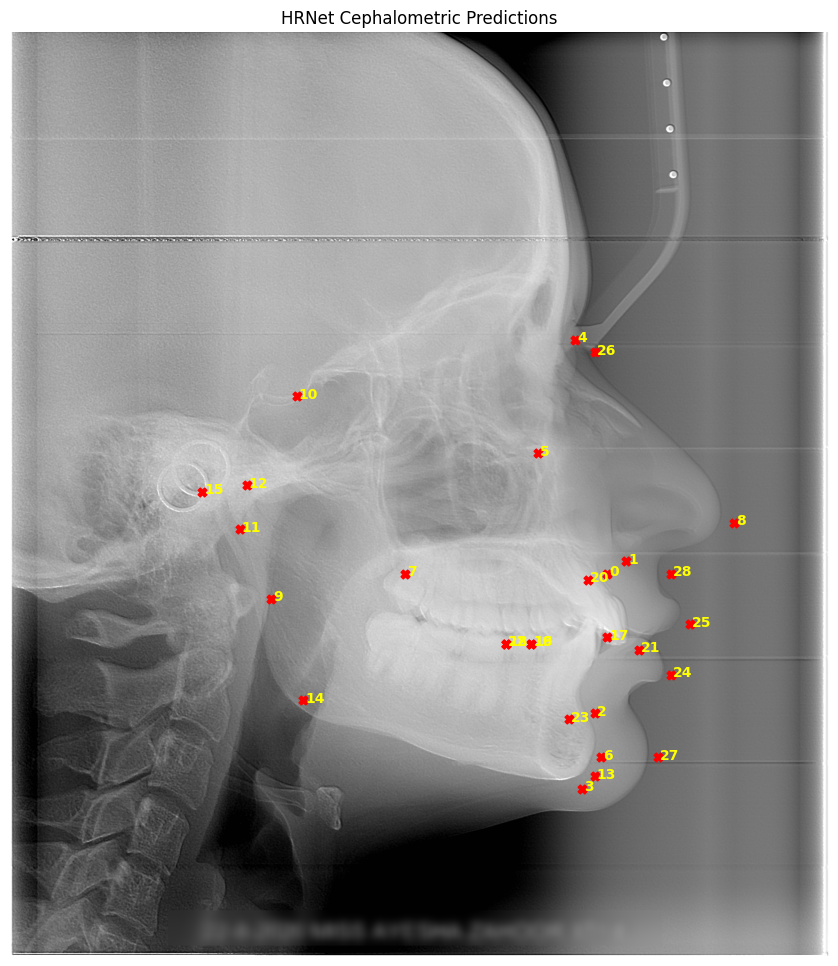

In [31]:
# --- TODO: UPDATE THIS PATH TO A REAL IMAGE ---
test_image_path = 'data/test/Cephalograms/cks2ip8fp29yl0yuf6ry9266i.png'
input_size = config.MODEL.IMAGE_SIZE
heatmap_size = config.MODEL.HEATMAP_SIZE

if os.path.exists(test_image_path):
    img_tensor, original_img, center, scale = preprocess_image(test_image_path, input_size)
    img_tensor = img_tensor.to(device)
    
    # 1. Run the Model Forward Pass
    with torch.no_grad():
        output = model(img_tensor)
        score_map = output.data.cpu()
        print(score_map.shape)  # Should be [1, 29, 128, 128]
        # 2. Decode the 128x128 heatmaps back to raw 512x512 coordinates
        center_batch = center.unsqueeze(0)
        scale_batch = torch.Tensor([scale])
        
        preds = decode_preds(score_map, center_batch, scale_batch, heatmap_size)
        preds = preds.squeeze(0).numpy() # Yields shape: [29, 2]
        print(preds.shape)
        
    # 3. Visualize
    plt.figure(figsize=(12, 12))
    plt.imshow(original_img)
    
    # Plot predicted points as red X markers
    plt.scatter(preds[:, 0], preds[:, 1], c='red', s=40, marker='X')
    
    # Annotate landmark index numbers next to the points
    for i, (x, y) in enumerate(preds):
        plt.text(x + 5, y + 5, str(i), color='yellow', fontsize=10, fontweight='bold')
        
    plt.axis('off')
    plt.title('HRNet Cephalometric Predictions')
    plt.show()

else:
    print(f"Cannot find image at: {test_image_path}. Please update the path!")

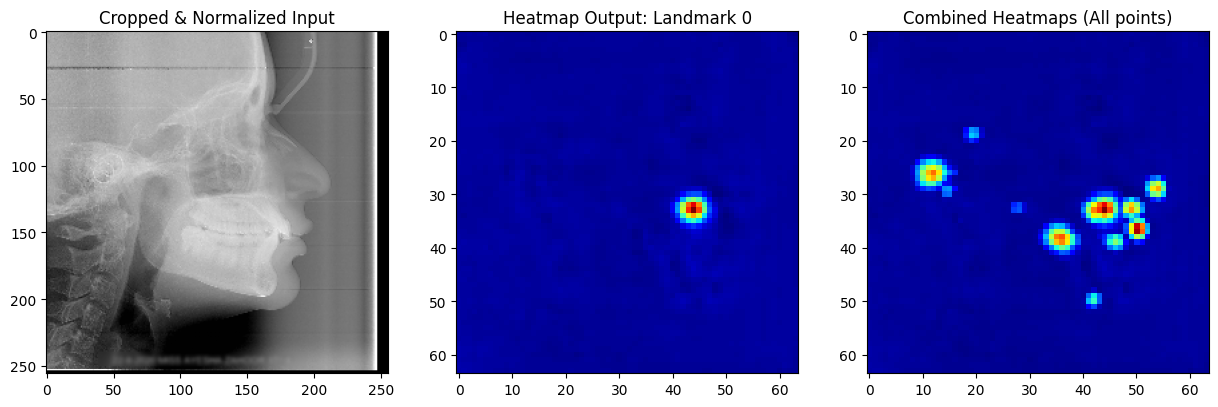

In [32]:
# Debugging the heatmap directly to inspect model confidence
img_tensor, original_img, center, scale = preprocess_image(test_image_path, input_size)
img_tensor = img_tensor.to(device)

with torch.no_grad():
    output = model(img_tensor)
    score_map = output.data.cpu().numpy()

plt.figure(figsize=(15, 5))
# Plot original processed image (just the first channel for reference)
plt.subplot(1, 3, 1)
plt.imshow(img_tensor[0].permute(1, 2, 0).cpu().numpy()[:, :, 0], cmap='gray')
plt.title("Cropped & Normalized Input")

# Plot Heatmap for Landmark 0 (A-point)
plt.subplot(1, 3, 2)
plt.imshow(score_map[0, 0, :, :], cmap='jet')
plt.title("Heatmap Output: Landmark 0")

# Plot combined Heatmaps for all 29 points
plt.subplot(1, 3, 3)
combined_heatmap = np.max(score_map[0], axis=0) # Get max probability across all landmarks
plt.imshow(combined_heatmap, cmap='jet')
plt.title("Combined Heatmaps (All points)")

plt.show()